# Schedulable Parameters

We optimise the 2‑D Rastrigin function with a GA while **two** parameters
change over time:
1. **Mutation scale** – a `LinearSchedule` from 0.5 to 0.01.
2. **Mutation probability** – a `StepSchedule` that starts high (0.8) for
    exploration, then drops to 0.1 after 40 % of the generations for
    exploitation.

We’ll run the algorithm manually and plot the schedules together with the
best fitness.

In [10]:
import matplotlib.pyplot as plt
import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import Rastrigin
from metaheuristic_designer.parameter_schedules import (
    LinearSchedule, StepSchedule,
)

rng = mhd.check_random_state(42)

## 1. Objective function

In [11]:
DIM = 2
objfunc = Rastrigin(DIM, mode="min")

## 2. Schedules

- `mutation_scale`: linearly from 0.5 → 0.01
- `mutation_prob`: 0.8 until progress 0.4, then 0.1

In [12]:
mutation_scale = LinearSchedule(init_value=0.5, final_value=0.001)
mutation_prob  = StepSchedule({0.0: 0.8, 0.4: 0.1})

Check schedules for different progres values

In [13]:
print("Mutation scale at 0, 0.5, 1.0:", mutation_scale(0.0), mutation_scale(0.5), mutation_scale(1.0))
print("Mutation prob  at 0, 0.3, 0.5:", mutation_prob(0.0), mutation_prob(0.3), mutation_prob(0.5))

Mutation scale at 0, 0.5, 1.0: 0.5 0.2505 0.001
Mutation prob  at 0, 0.3, 0.5: 0.8 0.8 0.1


## 3. Operator with scheduled parameters

We decompose the operator into a `BranchOperator` that decides *whether* to
mutate (prob) and a composite that applies mutation (scale).

The library’s `BranchOperator` already accepts a probability as a `p` parameter.
We can replace that probability with our schedule.  Mutation scale is the `F`
parameter of the Gaussian mutation.

In [14]:
mut_op = mhd.operators.create_operator(
    "mutation.gaussian_mutation",
    N=1,
    F=mutation_scale,          # scheduled strength
    random_state=rng,
)

# BranchOperator: with probability = mutation_prob, apply mut_op; otherwise do nothing
evolve_op = mhd.operators.BranchOperator(
    [mut_op, mhd.operators.NullOperator()],
    method="Random",
    p=mutation_prob,           # scheduled probability
    random_state=rng,
)

## 4. Fixed selections

In [15]:
survivor_sel = mhd.survivor_selection_methods.create_survivor_selection(
    "one_to_one", random_state=rng,
)

## 5. Build strategy and algorithm

In [16]:
strategy = mhd.SearchStrategy(
    initializer=mhd.initializers.UniformInitializer(
        DIM, -5.12, 5.12, pop_size=30, random_state=rng),
    operator=evolve_op,
    survivor_sel=survivor_sel,
    random_state=rng,
)
algo = mhd.algorithms.StandardAlgorithm(
    objfunc, strategy, ngen=100, stop_cond="ngen", verbose=False,
)

## 6. Run manually, recording schedule values

After each step, we retrieve the current parameter values from the
operators we defined earlier.

In [ ]:
scale_history, prob_history, fit_history = [], [], []
algo.initialize()
for gen in range(100):
    algo.step()              # Run one step of the algorithm 
    algo.update()            # Update the stopping condition and progress 
    scale_history.append(mut_op.get_params()["F"])
    prob_history.append(evolve_op.get_params()["p"])
    _, best_fit = algo.best_solution()
    fit_history.append(best_fit)

## 7. Visualise everything

scale history: [0.5, 0.49501, 0.49002, 0.48502999999999996, 0.48003999999999997, 0.47505, 0.47006, 0.46507, 0.46008000000000004, 0.45509, 0.4501, 0.44511, 0.44012, 0.43513, 0.43013999999999997, 0.42515, 0.42016, 0.41517, 0.41018000000000004, 0.40519000000000005, 0.4002, 0.39521, 0.39022, 0.38523, 0.38024, 0.37525, 0.37026, 0.36527, 0.36028, 0.35529, 0.3503, 0.34530999999999995, 0.34031999999999996, 0.33532999999999996, 0.33033999999999997, 0.32535000000000003, 0.32036000000000003, 0.31537, 0.31038, 0.30539, 0.3004, 0.29541000000000006, 0.29042, 0.28543, 0.28044, 0.27545000000000003, 0.27046000000000003, 0.26547000000000004, 0.26048, 0.25549, 0.2505, 0.24551, 0.24051999999999998, 0.23553, 0.23054, 0.22554999999999997, 0.22055999999999998, 0.21557, 0.21058000000000002, 0.20559000000000002, 0.2006, 0.19561, 0.19062, 0.18563, 0.18064, 0.17565, 0.17065999999999998, 0.16566999999999998, 0.16068, 0.15569000000000002, 0.15070000000000003, 0.14571, 0.14072, 0.13573000000000002, 0.13074, 0.12575

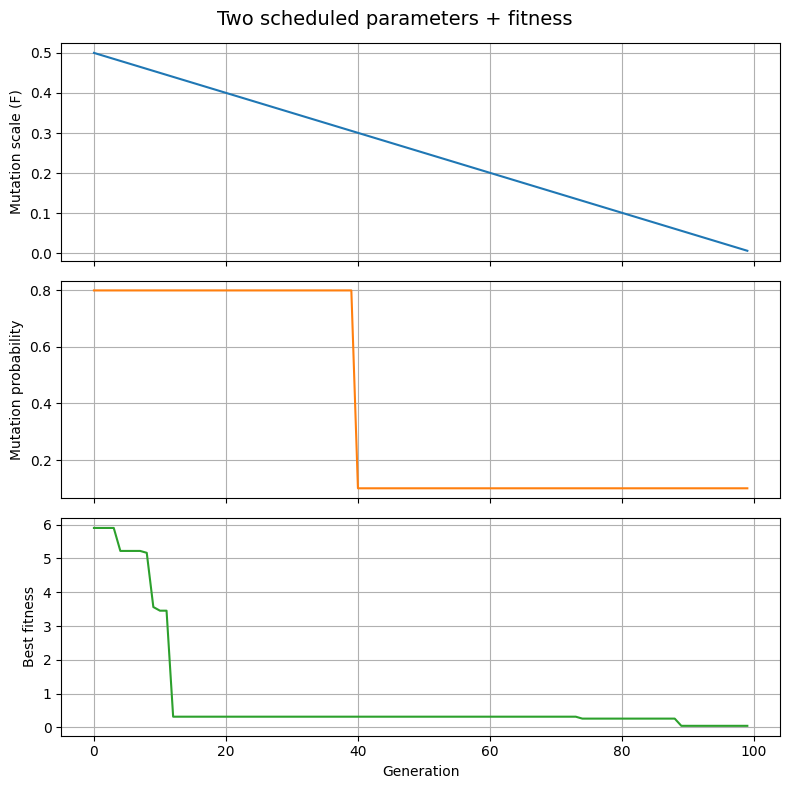

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(8, 8))

ax1.plot(scale_history, color="tab:blue")
ax1.set_ylabel("Mutation scale (F)")
ax1.grid(True)

ax2.plot(prob_history, color="tab:orange")
ax2.set_ylabel("Mutation probability")
ax2.grid(True)

ax3.plot(fit_history, color="tab:green")
ax3.set_xlabel("Generation")
ax3.set_ylabel("Best fitness")
ax3.grid(True)

plt.suptitle("Two scheduled parameters + fitness", fontsize=14)
plt.tight_layout()
plt.show()

This example shows how easy it is to combine multiple schedules.
You can replace the step schedule with a `LogisticSchedule` for smooth
transitions, or even wrap a `RandomSchedule` for stochastic exploration.